# EDA Deepening and Feature Selection

This notebook converts the dataset understanding from Notebook 01 into model-ready decisions. The objective is to analyze sensor usefulness, feature variability, degradation trends, correlation with RUL, and prepare a defensible feature set for baseline modelling.

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

DATA_DIR = '../data/raw/CMAPSS/'
FIG_DIR = '../reports/figures/'
TBL_DIR = '../reports/tables/'

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TBL_DIR, exist_ok=True)

## 2. Load FD001 Data with RUL

Reusing the loading and RUL construction logic from Notebook 01.

In [2]:
# Column schema
index_cols = ['unit_number', 'time_in_cycles']
op_cols = [f'operational_setting_{i}' for i in range(1, 4)]
sensor_cols = [f'sensor_measurement_{i}' for i in range(1, 22)]
all_cols = index_cols + op_cols + sensor_cols

# Load data
train_df = pd.read_csv(f'{DATA_DIR}train_FD001.txt', sep='\\s+', header=None, names=all_cols)
test_df = pd.read_csv(f'{DATA_DIR}test_FD001.txt', sep='\\s+', header=None, names=all_cols)
rul_df = pd.read_csv(f'{DATA_DIR}RUL_FD001.txt', sep='\\s+', header=None, names=['RUL'])

# Train RUL: max cycle - current cycle
max_cycles = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycle']
train_df = train_df.merge(max_cycles, on='unit_number', how='left')
train_df['RUL'] = train_df['max_cycle'] - train_df['time_in_cycles']
train_df.drop(columns=['max_cycle'], inplace=True)

# Test RUL: estimated failure cycle - current cycle
test_max_cycles = test_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
test_max_cycles.columns = ['unit_number', 'last_test_cycle']
rul_df_indexed = rul_df.copy()
rul_df_indexed['unit_number'] = range(1, len(rul_df) + 1)
test_max_cycles = test_max_cycles.merge(rul_df_indexed, on='unit_number', how='left')
test_max_cycles['estimated_failure_cycle'] = test_max_cycles['last_test_cycle'] + test_max_cycles['RUL']
test_df = test_df.merge(
    test_max_cycles[['unit_number', 'estimated_failure_cycle']],
    on='unit_number', how='left'
)
test_df['RUL'] = test_df['estimated_failure_cycle'] - test_df['time_in_cycles']
test_df.drop(columns=['estimated_failure_cycle'], inplace=True)

print(f'Train: {train_df.shape}, Test: {test_df.shape}')
print(f'Train RUL range: [{train_df["RUL"].min()}, {train_df["RUL"].max()}]')
print(f'Test RUL range:  [{test_df["RUL"].min()}, {test_df["RUL"].max()}]')

Train: (20631, 27), Test: (13096, 27)
Train RUL range: [0, 361]
Test RUL range:  [7, 340]


## 3. Feature Categorization

Categorize all columns by their role in the modelling pipeline.

| Feature Group | Columns | Use in Modelling? | Reason |
|---|---|---|---|
| ID column | `unit_number` | No | Identifier only |
| Time column | `time_in_cycles` | Maybe | Useful for sequencing, but can leak lifecycle position if misused directly |
| Operating settings | `operational_setting_1..3` | Review | FD001 has one operating condition, so variation may be limited |
| Sensor columns | `sensor_measurement_1..21` | Yes, after filtering | Main degradation signals |
| Target | `RUL` | Yes | Regression target |

## 4. Feature Profile

Build a detailed profile for each candidate feature to support filtering decisions.

In [3]:
feature_cols = op_cols + sensor_cols

feature_profile = pd.DataFrame({
    'feature': feature_cols,
    'unique_count': [train_df[c].nunique() for c in feature_cols],
    'missing': [train_df[c].isnull().sum() for c in feature_cols],
    'min': [train_df[c].min() for c in feature_cols],
    'max': [train_df[c].max() for c in feature_cols],
    'mean': [train_df[c].mean() for c in feature_cols],
    'std': [train_df[c].std() for c in feature_cols],
    'variance': [train_df[c].var() for c in feature_cols],
})

feature_profile['is_constant'] = feature_profile['variance'] == 0
feature_profile['is_near_constant'] = (
    (feature_profile['unique_count'] <= 3) | (feature_profile['variance'] < 0.0001)
)

print(feature_profile.to_string(index=False))

              feature  unique_count  missing       min       max        mean          std     variance  is_constant  is_near_constant
operational_setting_1           158        0   -0.0087    0.0087   -0.000009 2.187313e-03 4.784340e-06        False              True
operational_setting_2            13        0   -0.0006    0.0006    0.000002 2.930621e-04 8.588541e-08        False              True
operational_setting_3             1        0  100.0000  100.0000  100.000000 0.000000e+00 0.000000e+00         True              True
 sensor_measurement_1             1        0  518.6700  518.6700  518.670000 0.000000e+00 0.000000e+00         True              True
 sensor_measurement_2           310        0  641.2100  644.5300  642.680934 5.000533e-01 2.500533e-01        False             False
 sensor_measurement_3          3012        0 1571.0400 1616.9100 1590.523119 6.131150e+00 3.759099e+01        False             False
 sensor_measurement_4          4051        0 1382.2500 1441.49

## 5. Constant and Near-Constant Sensor Identification

Classify each feature into categories based on variance and unique value count.

In [4]:
# Classify sensors
constant_sensors = feature_profile[feature_profile['is_constant']]['feature'].tolist()
near_constant_sensors = feature_profile[
    feature_profile['is_near_constant'] & ~feature_profile['is_constant']
]['feature'].tolist()
variable_sensors = feature_profile[
    ~feature_profile['is_near_constant']
]['feature'].tolist()

print(f'Constant features ({len(constant_sensors)}):      {constant_sensors}')
print(f'Near-constant features ({len(near_constant_sensors)}): {near_constant_sensors}')
print(f'Variable features ({len(variable_sensors)}):      {variable_sensors}')

Constant features (5):      ['operational_setting_3', 'sensor_measurement_1', 'sensor_measurement_10', 'sensor_measurement_18', 'sensor_measurement_19']
Near-constant features (5): ['operational_setting_1', 'operational_setting_2', 'sensor_measurement_5', 'sensor_measurement_6', 'sensor_measurement_16']
Variable features (14):      ['sensor_measurement_2', 'sensor_measurement_3', 'sensor_measurement_4', 'sensor_measurement_7', 'sensor_measurement_8', 'sensor_measurement_9', 'sensor_measurement_11', 'sensor_measurement_12', 'sensor_measurement_13', 'sensor_measurement_14', 'sensor_measurement_15', 'sensor_measurement_17', 'sensor_measurement_20', 'sensor_measurement_21']


## 6. Sensor-RUL Correlation Ranking

Rank variable sensors by their Pearson correlation with RUL. This is an initial relevance signal, not final feature importance.

In [5]:
# Correlation with RUL for variable sensors only
corr_with_rul = train_df[variable_sensors + ['RUL']].corr()['RUL'].drop('RUL')
corr_with_rul = corr_with_rul.sort_values(key=abs, ascending=False)

corr_ranking = pd.DataFrame({
    'feature': corr_with_rul.index,
    'correlation_with_rul': corr_with_rul.values,
    'abs_correlation': np.abs(corr_with_rul.values)
})

print(corr_ranking.to_string(index=False))

              feature  correlation_with_rul  abs_correlation
sensor_measurement_11             -0.696228         0.696228
 sensor_measurement_4             -0.678948         0.678948
sensor_measurement_12              0.671983         0.671983
 sensor_measurement_7              0.657223         0.657223
sensor_measurement_15             -0.642667         0.642667
sensor_measurement_21              0.635662         0.635662
sensor_measurement_20              0.629428         0.629428
 sensor_measurement_2             -0.606484         0.606484
sensor_measurement_17             -0.606154         0.606154
 sensor_measurement_3             -0.584520         0.584520
 sensor_measurement_8             -0.563968         0.563968
sensor_measurement_13             -0.562569         0.562569
 sensor_measurement_9             -0.390102         0.390102
sensor_measurement_14             -0.306769         0.306769


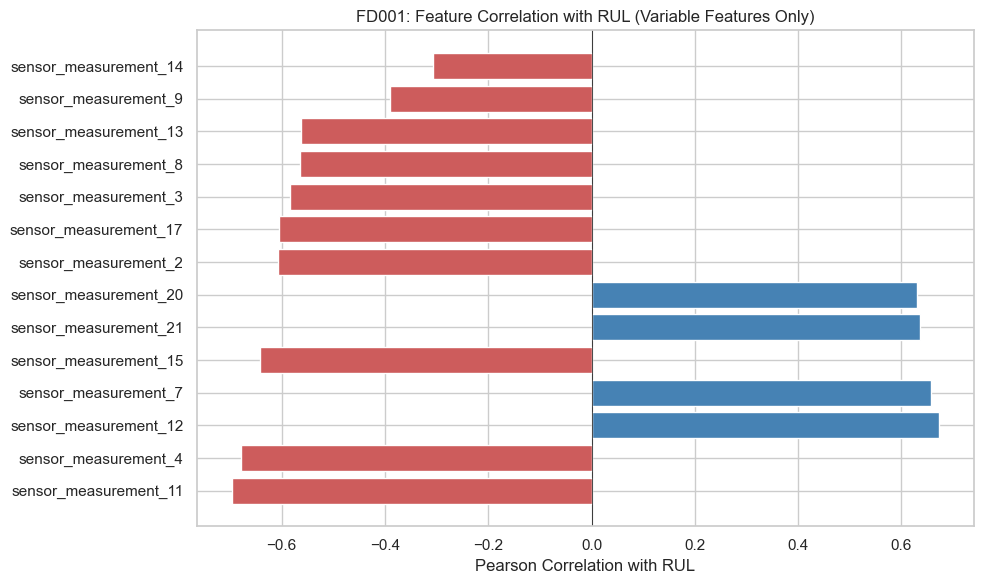

In [6]:
# Bar plot of absolute correlation with RUL
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if v > 0 else 'indianred' for v in corr_ranking['correlation_with_rul']]
ax.barh(corr_ranking['feature'], corr_ranking['correlation_with_rul'], color=colors)
ax.set_xlabel('Pearson Correlation with RUL')
ax.set_title('FD001: Feature Correlation with RUL (Variable Features Only)')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}feature_correlation_ranking_fd001.png', dpi=150)
plt.show()

## 7. Sensor Degradation Trends

For each variable sensor, plot trends over the engine lifecycle for a few sample engines. This helps identify whether a sensor shows a visible degradation pattern or just noise.

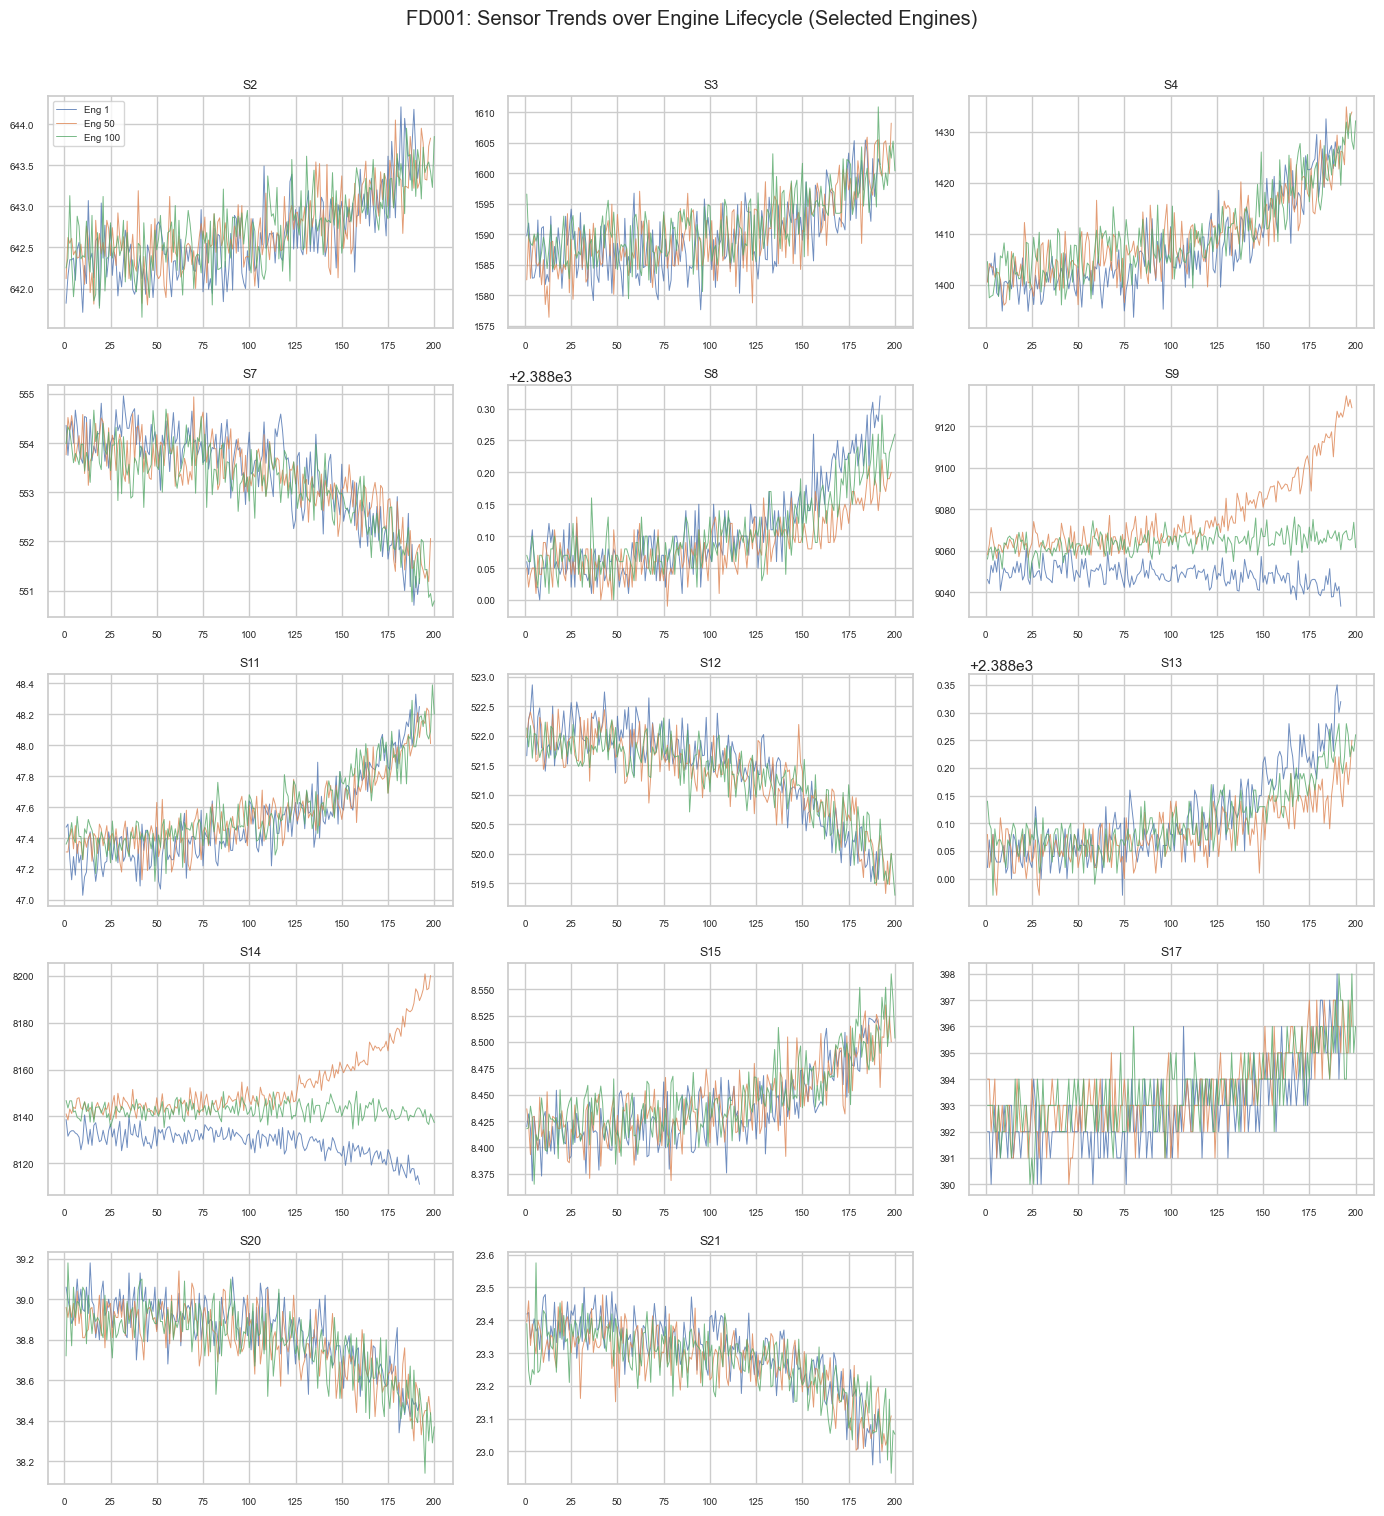

In [7]:
# Plot sensor trends for variable sensors across 3 sample engines
sample_units = [1, 50, 100]
variable_sensor_cols = [c for c in variable_sensors if c.startswith('sensor_measurement')]

n_sensors = len(variable_sensor_cols)
n_cols = 3
n_rows = int(np.ceil(n_sensors / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows))
axes = axes.flatten()

for i, sensor in enumerate(variable_sensor_cols):
    for unit in sample_units:
        unit_data = train_df[train_df['unit_number'] == unit]
        axes[i].plot(unit_data['time_in_cycles'], unit_data[sensor],
                     linewidth=0.7, alpha=0.8, label=f'Eng {unit}')
    axes[i].set_title(sensor.replace('sensor_measurement_', 'S'), fontsize=9)
    axes[i].tick_params(labelsize=7)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=7)
plt.suptitle('FD001: Sensor Trends over Engine Lifecycle (Selected Engines)', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}sensor_trends_selected_fd001.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Sensor vs RUL Scatter

For the top correlated sensors, plot sensor value against RUL to check relationship shape.

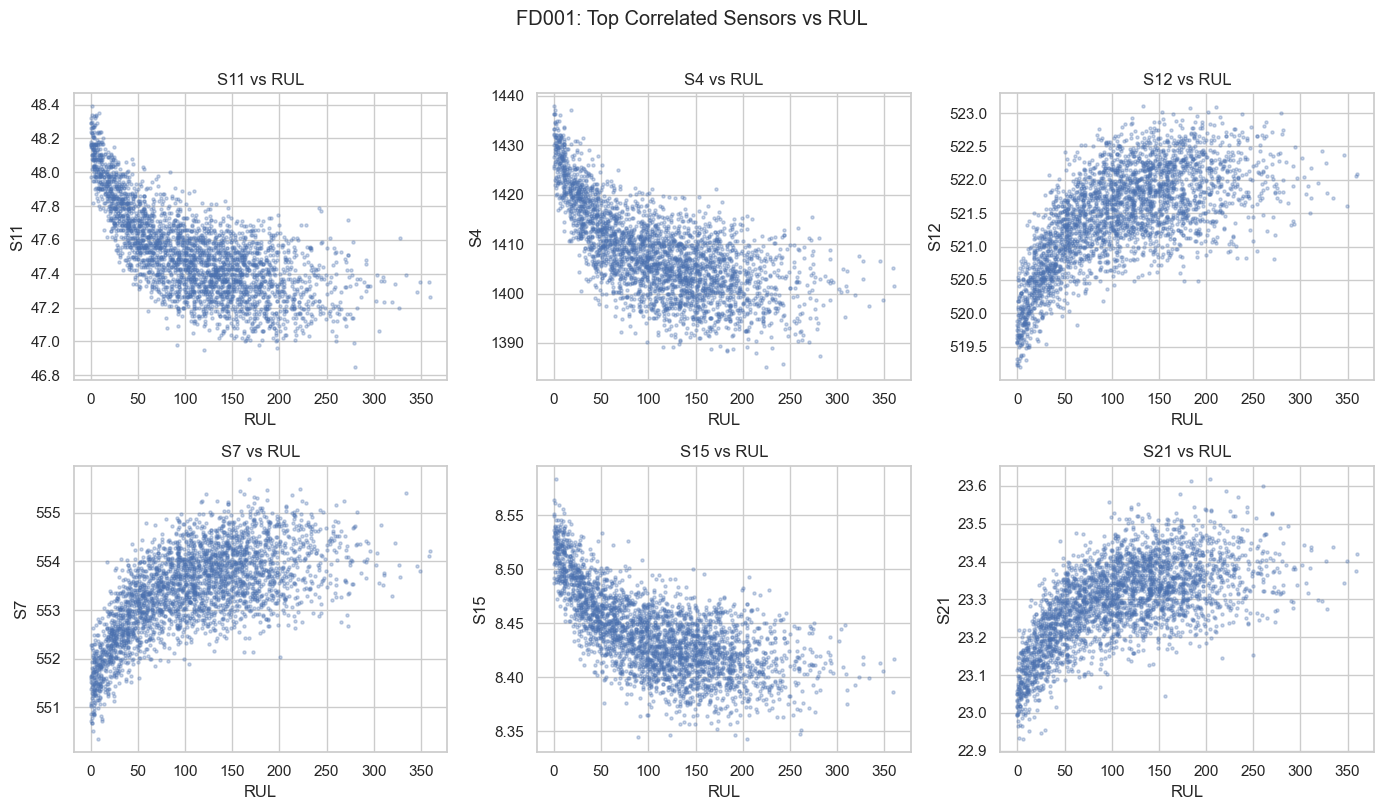

In [8]:
# Top 6 sensors by absolute correlation
top_sensors = corr_ranking.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

# Subsample for scatter performance
sample_df = train_df.sample(n=3000, random_state=42)

for i, sensor in enumerate(top_sensors):
    axes[i].scatter(sample_df['RUL'], sample_df[sensor], alpha=0.3, s=5)
    axes[i].set_xlabel('RUL')
    axes[i].set_ylabel(sensor.replace('sensor_measurement_', 'S'))
    axes[i].set_title(f'{sensor.replace("sensor_measurement_", "S")} vs RUL')

plt.suptitle('FD001: Top Correlated Sensors vs RUL', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}sensor_vs_rul_selected_fd001.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Decision Table

Consolidate sensor classification, correlation, and observed trend behaviour into one decision table.

In [9]:
# Build feature decision table
decisions = []

for feat in feature_cols:
    if feat in constant_sensors:
        category = 'Constant'
        decision = 'Drop candidate'
        corr_val = 0.0
    elif feat in near_constant_sensors:
        category = 'Near-constant'
        decision = 'Review'
        corr_val = train_df[[feat, 'RUL']].corr().iloc[0, 1]
        if pd.isna(corr_val):
            corr_val = 0.0
    else:
        category = 'Variable'
        corr_val = train_df[[feat, 'RUL']].corr().iloc[0, 1]
        if abs(corr_val) >= 0.5:
            decision = 'Keep'
        elif abs(corr_val) >= 0.2:
            decision = 'Keep'
        else:
            decision = 'Review'

    decisions.append({
        'feature': feat,
        'category': category,
        'correlation_with_rul': round(corr_val, 4),
        'abs_correlation': round(abs(corr_val), 4),
        'decision': decision
    })

decision_df = pd.DataFrame(decisions)
decision_df = decision_df.sort_values('abs_correlation', ascending=False).reset_index(drop=True)

decision_df.to_csv(f'{TBL_DIR}feature_decision_table_fd001.csv', index=False)
print(f'Saved to {TBL_DIR}feature_decision_table_fd001.csv')
print()
print(decision_df.to_string(index=False))

Saved to ../reports/tables/feature_decision_table_fd001.csv

              feature      category  correlation_with_rul  abs_correlation       decision
sensor_measurement_11      Variable               -0.6962           0.6962           Keep
 sensor_measurement_4      Variable               -0.6789           0.6789           Keep
sensor_measurement_12      Variable                0.6720           0.6720           Keep
 sensor_measurement_7      Variable                0.6572           0.6572           Keep
sensor_measurement_15      Variable               -0.6427           0.6427           Keep
sensor_measurement_21      Variable                0.6357           0.6357           Keep
sensor_measurement_20      Variable                0.6294           0.6294           Keep
 sensor_measurement_2      Variable               -0.6065           0.6065           Keep
sensor_measurement_17      Variable               -0.6062           0.6062           Keep
 sensor_measurement_3      Variable    

## 10. Define Baseline Feature Sets

Based on the feature analysis, define three feature sets for baseline experiments.

In [10]:
# Feature Set A: Full raw features (all operational settings + all sensors)
feature_set_a = op_cols + sensor_cols

# Feature Set B: Filtered features (remove constant and near-constant)
feature_set_b = decision_df[
    decision_df['decision'].isin(['Keep'])
]['feature'].tolist()

# Feature Set C: Filtered + placeholder for derived features (to be built in Step 3)
feature_set_c = feature_set_b.copy()  # Will be extended with derived features later

print(f'Feature Set A (full raw):     {len(feature_set_a)} features')
print(f'  {feature_set_a}')
print()
print(f'Feature Set B (filtered):     {len(feature_set_b)} features')
print(f'  {feature_set_b}')
print()
print(f'Feature Set C (filtered + derived): {len(feature_set_c)} features (derived to be added in Step 3)')
print(f'  {feature_set_c}')

# Save selected features
selected_features = pd.DataFrame({
    'feature': feature_set_b,
    'source': ['raw'] * len(feature_set_b)
})
selected_features.to_csv(f'{TBL_DIR}selected_features_fd001.csv', index=False)
print(f'\nSaved selected features to {TBL_DIR}selected_features_fd001.csv')

Feature Set A (full raw):     24 features
  ['operational_setting_1', 'operational_setting_2', 'operational_setting_3', 'sensor_measurement_1', 'sensor_measurement_2', 'sensor_measurement_3', 'sensor_measurement_4', 'sensor_measurement_5', 'sensor_measurement_6', 'sensor_measurement_7', 'sensor_measurement_8', 'sensor_measurement_9', 'sensor_measurement_10', 'sensor_measurement_11', 'sensor_measurement_12', 'sensor_measurement_13', 'sensor_measurement_14', 'sensor_measurement_15', 'sensor_measurement_16', 'sensor_measurement_17', 'sensor_measurement_18', 'sensor_measurement_19', 'sensor_measurement_20', 'sensor_measurement_21']

Feature Set B (filtered):     14 features
  ['sensor_measurement_11', 'sensor_measurement_4', 'sensor_measurement_12', 'sensor_measurement_7', 'sensor_measurement_15', 'sensor_measurement_21', 'sensor_measurement_20', 'sensor_measurement_2', 'sensor_measurement_17', 'sensor_measurement_3', 'sensor_measurement_8', 'sensor_measurement_13', 'sensor_measurement_9',

## 11. Initial Multi-View Grouping

Define the initial views for the multi-view modelling approach.

| View | Features | Notes |
|---|---|---|
| Sensor view | Selected sensor measurements | Main degradation signals after filtering |
| Operating context view | Operational settings | Subject to usefulness evaluation; FD001 has one operating condition |
| Degradation feature view | Rolling mean, rolling std, slope, delta features | To be engineered in Step 3 |
| Temporal context | Cycle index or normalized age | Used carefully to avoid leaking lifecycle position |

**FD001 caveat**: In FD001, operating context may have limited variation because the subset has one operating condition. Therefore, the initial multi-view experiment will mainly compare raw sensor features and derived degradation features. Operating settings will be retained initially but evaluated for contribution.

In [11]:
# Define views explicitly
sensor_view_features = [f for f in feature_set_b if f.startswith('sensor_measurement')]
op_context_features = [f for f in feature_set_b if f.startswith('operational_setting')]

print('Multi-View Assignment:')
print(f'  Sensor view:      {len(sensor_view_features)} features')
print(f'    {sensor_view_features}')
print(f'  Operating context: {len(op_context_features)} features')
print(f'    {op_context_features}')
print(f'  Degradation view:  To be derived in Step 3')
print(f'  Temporal context:  time_in_cycles (used with care)')

Multi-View Assignment:
  Sensor view:      14 features
    ['sensor_measurement_11', 'sensor_measurement_4', 'sensor_measurement_12', 'sensor_measurement_7', 'sensor_measurement_15', 'sensor_measurement_21', 'sensor_measurement_20', 'sensor_measurement_2', 'sensor_measurement_17', 'sensor_measurement_3', 'sensor_measurement_8', 'sensor_measurement_13', 'sensor_measurement_9', 'sensor_measurement_14']
  Operating context: 0 features
    []
  Degradation view:  To be derived in Step 3
  Temporal context:  time_in_cycles (used with care)


## 12. EDA Modelling Implications

Summary of decisions and implications arising from this EDA step.

In [12]:
implications = pd.DataFrame({
    'finding': [
        'Constant sensors identified',
        'Near-constant sensors identified',
        'Strong RUL correlation in multiple sensors',
        'Operating settings have very low variance in FD001',
        'Visible degradation trends in several sensors',
        'Linear and monotonic relationships with RUL observed',
        'FD001 has one operating condition',
    ],
    'implication': [
        'Drop from modelling; zero information content',
        'Review individually; likely drop unless justified',
        'These form the core of the sensor view for modelling',
        'Operating context view may have limited value in FD001; retain and evaluate',
        'Derived degradation features (rolling stats, slopes) are justified',
        'Linear baselines (Ridge, SVR) may work; non-linear models should improve further',
        'Multi-view operating-context analysis better suited for FD002/FD004',
    ],
    'action': [
        'Remove from Feature Set B',
        'Exclude from Feature Set B unless manually justified',
        'Include in Feature Set B and sensor view',
        'Include in Feature Set A; evaluate contribution in experiments',
        'Engineer in Step 3 for Feature Set C',
        'Use both linear and non-linear baselines in Step 4',
        'Note as limitation; extend to multi-condition subsets later',
    ]
})

implications.to_csv(f'{TBL_DIR}eda_modelling_implications_fd001.csv', index=False)
print(f'Saved to {TBL_DIR}eda_modelling_implications_fd001.csv')
print()
print(implications.to_string(index=False))

Saved to ../reports/tables/eda_modelling_implications_fd001.csv

                                             finding                                                                      implication                                                         action
                         Constant sensors identified                                    Drop from modelling; zero information content                                      Remove from Feature Set B
                    Near-constant sensors identified                                Review individually; likely drop unless justified           Exclude from Feature Set B unless manually justified
          Strong RUL correlation in multiple sensors                             These form the core of the sensor view for modelling                       Include in Feature Set B and sensor view
  Operating settings have very low variance in FD001      Operating context view may have limited value in FD001; retain and evaluate Include in Fe

## 13. Summary

1. Constant sensors (zero variance) have been identified and marked for removal.
2. Near-constant sensors have been flagged for review; excluded from the filtered feature set.
3. Variable sensors with meaningful RUL correlation form the baseline feature set.
4. Operating settings show very low variance in FD001 and will be retained for evaluation but are not expected to contribute strongly.
5. Sensor degradation trends are visible in multiple channels, supporting time-window-based models.
6. Three feature sets are defined: full raw (A), filtered (B), and filtered + derived (C, to be built in Step 3).
7. Initial multi-view grouping is defined: sensor view, operating context view, degradation feature view, and temporal context.

Next step: baseline-ready preprocessing (scaling, RUL capping, windowing, train/val split).

In [13]:
print("Generated tables:")
for f in sorted(os.listdir(TBL_DIR)):
    print("-", f)

print("\nGenerated figures:")
for f in sorted(os.listdir(FIG_DIR)):
    print("-", f)

Generated tables:
- .gitkeep
- data_quality_summary_fd001.csv
- dataset_summary_fd001.csv
- eda_modelling_implications_fd001.csv
- feature_decision_table_fd001.csv
- feature_profile_fd001.csv
- selected_features_fd001.csv
- sensor_rul_correlation_fd001.csv
- train_test_distribution_check_fd001.csv

Generated figures:
- .gitkeep
- correlation_heatmap_fd001.png
- cycle_count_distribution_fd001.png
- feature_correlation_ranking_fd001.png
- rul_distribution_fd001.png
- sample_rul_curves_fd001.png
- sample_sensor_trends_fd001.png
- sensor_trends_selected_fd001.png
- sensor_vs_rul_selected_fd001.png
